In [118]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from utils import *

In [119]:
# optical tweezers data

files = ['/Users/ursic/Downloads/opticaltweezers_intg1.csv', '/Users/ursic/Downloads/opticaltweezers_intg2.csv', '/Users/ursic/Downloads/opticaltweezers_metg1.csv', '/Users/ursic/Downloads/opticaltweezers_metg2.csv']


measurements = ['Int G_1', 'Int G_2', 'Met G_1', 'Met G_2']

df_OT_all = pd.DataFrame()
for (measurement, file) in zip(measurements, files):
    df_OT = pd.read_csv(file, names=[f'Rep {i}' for i in range(len(pd.read_csv(file, nrows=1).columns))])
    df_OT['Measurement'] = measurement

    for rep in range(len(pd.read_csv(file, nrows=1).columns)):
        for i in range(len(df_OT)):
            line = df_OT[f'Rep {rep}'].values[i].replace('{', '').replace('}', '').split(', ')
            df_OT.loc[i, 'freq [Hz]'] = float(line[0])
            df_OT.loc[i, f'Rep {rep}'] = float(line[1])
    
    df_OT_all = pd.concat([df_OT_all, df_OT], ignore_index=True)

df_OT_all.head()

,Rep 0,Rep 1,Rep 2,Rep 3,Rep 4,Rep 5,Rep 6,Rep 7,Rep 8,Rep 9,Rep 10,Rep 11,Rep 12,Measurement,freq [Hz]
0,1.391158,0.912267,0.959591,0.266865,0.971147,0.229768,1.525496,0.512431,0.642814,0.42949,1.171444,0.622651,1.330943,Int G_1,0.5
1,2.33911,0.532764,0.654931,0.541523,1.444879,0.731844,1.678443,0.971404,0.3966,0.6347,2.452058,0.78981,1.360988,Int G_1,1.0
2,1.74625,1.80046,1.479992,1.042903,2.550393,0.71302,1.828755,0.777175,0.894055,0.853994,3.271821,1.694538,1.2677,Int G_1,2.0
3,1.979198,1.91481,2.087282,1.75425,2.641923,1.405469,2.352281,0.840213,1.205819,0.928861,6.570719,1.28113,2.477495,Int G_1,4.0
4,3.305024,4.308892,2.685079,2.132748,4.906074,1.353849,2.913643,1.944911,1.385114,1.539713,8.69267,1.478335,3.72936,Int G_1,8.0


In [120]:
for i in range(len(df_OT_all)):
    df_OT_all.loc[i, 'avg'] = np.average([df_OT_all.loc[i, f'Rep {j}'] for j in range(12)])
    df_OT_all.loc[i, 'std'] = np.std([df_OT_all.loc[i, f'Rep {j}'] for j in range(12)])/12

In [121]:
def phenom_curve(t, a, b, c, d):
    return a*t + b + c * np.exp((-d*t))

In [122]:
# Convert the creep responce to J(t)=6 π R x(t)/f(t),

D = 2.8 # um # Bead diameter
R = D/2

min_freq = 1/4.5
max_freq = 1/0.5

df_creep_all = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/averaged_curves_per_embryo/averaged_curves_no_subtr_bck.csv')

df_converted_data = pd.DataFrame(columns=['freq [Hz]'])

fig = plt.figure(figsize=(8, 6), dpi=300)
for embryo in df_creep_all['EMBRYO'].unique():
    df_creep = df_creep_all[df_creep_all['EMBRYO']==embryo]
    for (color_palette, mt_status) in zip([sns.color_palette('tab10'), sns.color_palette('dark')], ['y', 'n']):

        if len(df_creep[df_creep['MT_STATUS']==mt_status]) == 0:
            continue
            
        try:    
            t = df_creep.loc[(df_creep['MT_STATUS']==mt_status)&(df_creep['MAGNET_STATUS']>0.9), 'NORMALIZED_TIME'].values
            x = df_creep.loc[(df_creep['MT_STATUS']==mt_status)&(df_creep['MAGNET_STATUS']>0.9), 'DISPLACEMENT [um]'].values
            f = df_creep.loc[(df_creep['MT_STATUS']==mt_status)&(df_creep['MAGNET_STATUS']>0.9), 'FORCE [pN]'].values
            J = 6 * np.pi * R * x / f

            # Get G*

            g = lambda omega, eta, J0: complex(0, omega*J0) + (1 - np.exp(complex(0, -omega*t[1])))*(J[1]-J0)/t[1] + 1/eta * np.exp(complex(0, -omega*t[-1])) + np.sum([ (J[i]-J[i-1]) / (t[i]-t[i-1]) * (np.exp(complex(0, -omega*t[i-1]))-np.exp(complex(0, -omega*t[i]))) for i in range(2, len(t))])

            omega_values = np.linspace(min_freq, max_freq)

            popt, pcov = curve_fit(phenom_curve, t, J)
            J0 = popt[1] + popt[2]
            eta = 1/popt[0]

            # J0 = 0
            # eta = np.average(t[-3:-1] / (6 * np.pi * R * x / f)[-3:-1])

            print(eta, J0)

            for omega in omega_values:

                new_row = {'freq [Hz]': omega, 
                           'G_1': complex(0, omega/g(omega, eta, J0)).real, 
                           'G_2': complex(0, omega/g(omega, eta, J0)).imag, 
                           'MT_STATUS': mt_status, 
                           'EMBRYO': embryo,
                           'COUNT': df_creep['COUNT'].values[0]}
                df_converted_data = pd.concat([df_converted_data, pd.DataFrame(new_row, index=[0])], ignore_index=True)
                # plt.plot(omega, complex(0, omega/g(omega, eta, J0)).real, '.', color=color_palette[0], alpha=0.5)
                # plt.plot(omega, complex(0, omega/g(omega, eta, J0)).imag, '.', color=color_palette[1], alpha=0.5)
        
        except:
            print('One failed')

0.40722955121721 0.03202104348899126
3.0021797366198086 0.009491798077405633
3.707832390586064 0.007896322337429984
4.541986957838914 0.0021294236765219132
4.2085474012663315 0.003733280141698825
1.891014366253259 0.00405601045765569


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_54417/1770947293.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_converted_data = pd.concat([df_converted_data, pd.DataFrame(new_row, index=[0])], ignore_index=True)


2.3427926009083957 -0.0007193727960270735
6.724008450815969 9.24461430930057e-05
2.2154489686798695 0.001030351603549473
0.8002574699436992 0.010141344542832886
1.51621651576915 0.0031440118004363304
3.0547376549948453 -0.06788441382916766
2.510146769538884 -1.1102230246251565e-16
0.514040858203217 0.02374744845317922
3.687063507982514 0.0009800263779188856
One failed
5.67668660642041 0.003862493545891632


<Figure size 2400x1800 with 0 Axes>

In [123]:
df_converted_data.to_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/averaged_curves_per_embryo/converted_averaged_curves_no_subtr_bck.csv')
df_converted_data.head(10)

,freq [Hz],G_1,G_2,MT_STATUS,EMBRYO,COUNT
0,0.222222,-0.007557,0.092341,n,20240523s01p01,2.0
1,0.258503,-0.009920,0.108094,n,20240523s01p01,2.0
2,0.294785,-0.012447,0.124088,n,20240523s01p01,2.0
3,0.331066,-0.015067,0.140306,n,20240523s01p01,2.0
4,0.367347,-0.017708,0.156711,n,20240523s01p01,2.0
5,0.403628,-0.020303,0.173240,n,20240523s01p01,2.0
6,0.439909,-0.022802,0.189808,n,20240523s01p01,2.0
7,0.476190,-0.025171,0.206308,n,20240523s01p01,2.0
8,0.512472,-0.027409,0.222618,n,20240523s01p01,2.0
9,0.548753,-0.029545,0.238605,n,20240523s01p01,2.0


In [124]:
df_grouped_mean = df_converted_data[['freq [Hz]', 'G_1', 'G_2', 'MT_STATUS']].groupby(['freq [Hz]', 'MT_STATUS']).mean().reset_index()
df_grouped_std = df_converted_data[['freq [Hz]', 'G_1', 'G_2', 'MT_STATUS']].groupby(['freq [Hz]', 'MT_STATUS']).sem().reset_index()

df_grouped_mean.to_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_magtw_converted.csv')
df_grouped_mean.head()

,freq [Hz],MT_STATUS,G_1,G_2
0,0.222222,n,0.121076,0.219869
1,0.222222,y,0.287077,0.708900
2,0.258503,n,0.136518,0.237385
3,0.258503,y,0.354590,0.777186
4,0.294785,n,0.149788,0.253231


In [125]:
# bootstrapping 

df_bootstrapped_res = dict({})

for (param, mt_status) in zip(['G_1', 'G_2', 'G_1', 'G_2'], ['y', 'y', 'n', 'n']):
    data_groups = []
    df = df_converted_data.loc[df_converted_data['MT_STATUS']==mt_status]
    weights = df['COUNT'].unique()
    for embryo in df['EMBRYO'].unique():
        data_groups.append(df.loc[df['EMBRYO']==embryo, param])
    mean, ci = weighted_bootstrap(np.array(data_groups), weights=weights)

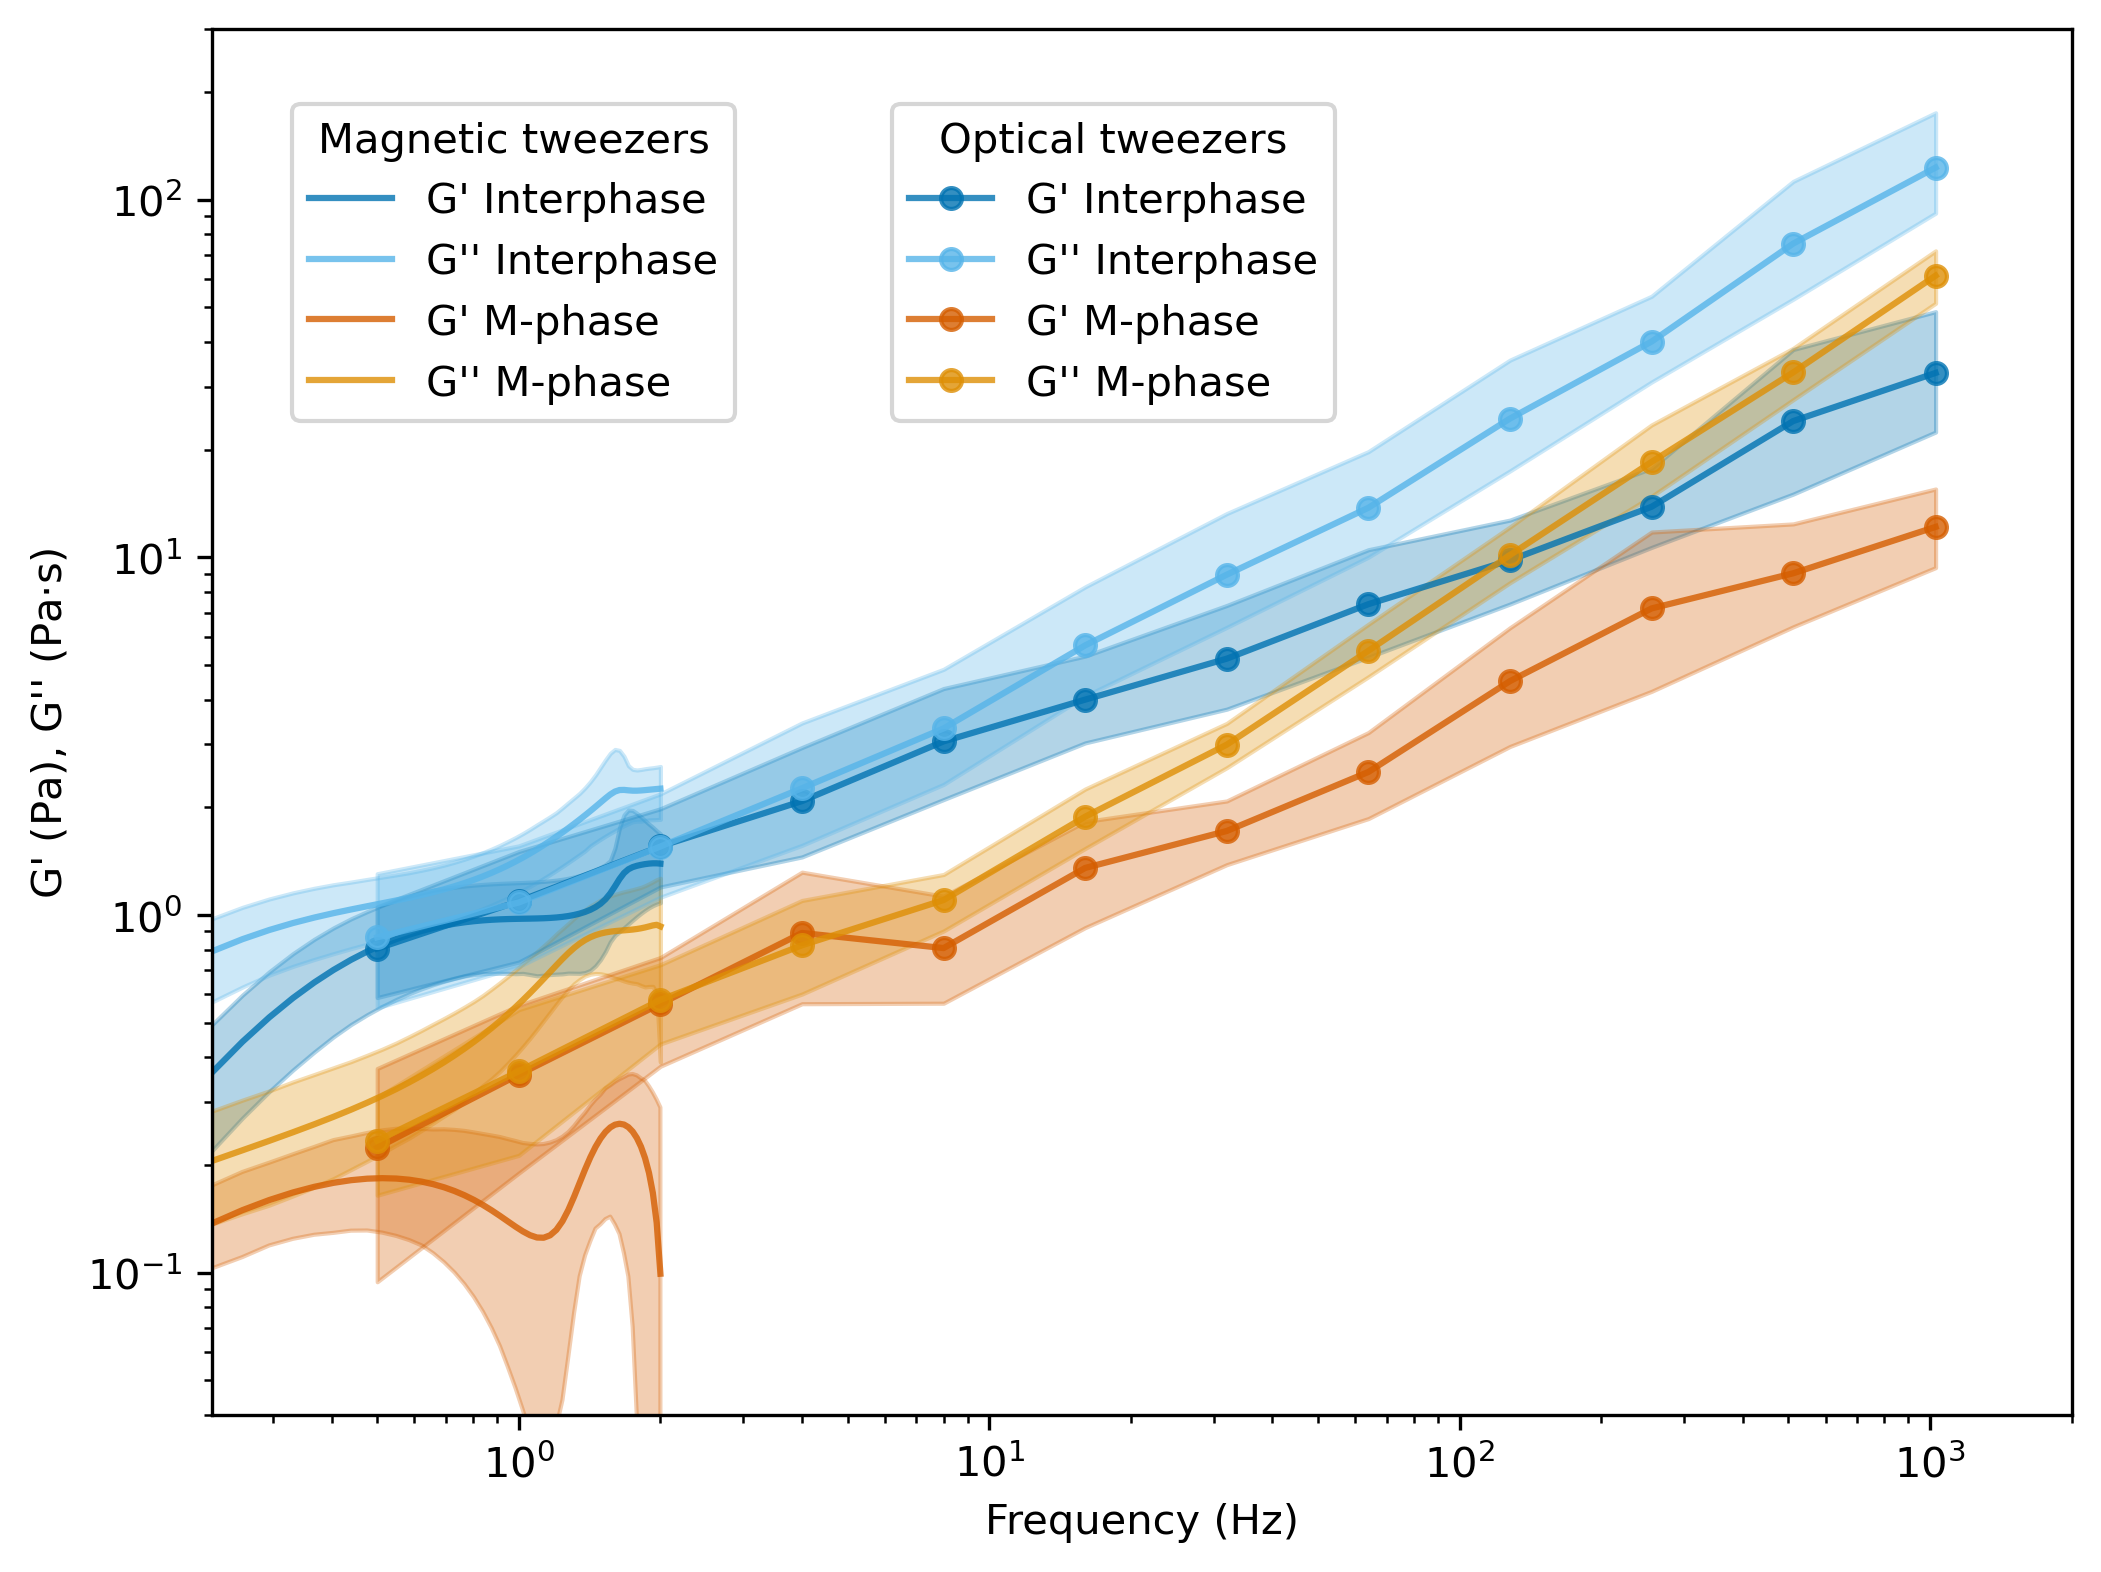

In [126]:
fig = plt.figure(figsize=(8, 6), dpi=300)

colors = [sns.color_palette('colorblind')[0], sns.color_palette('colorblind')[9], sns.color_palette('colorblind')[3], sns.color_palette('colorblind')[1]]



for (color, param, mt_status, label) in zip (colors, ['G_1', 'G_2', 'G_1', 'G_2'], ['y', 'y', 'n', 'n'], ['G\' Interphase', 'G\'\' Interphase', 'G\' M-phase', 'G\'\' M-phase']): 
    data_groups = []
    df = df_converted_data.loc[df_converted_data['MT_STATUS']==mt_status]
    weights = df['COUNT'].unique()
    for embryo in df['EMBRYO'].unique():
        data_groups.append(df.loc[df['EMBRYO']==embryo, param])

    mean, ci = weighted_bootstrap(np.array(data_groups), weights=weights)

    plt.plot(df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, 'freq [Hz]'], mean, '-', color=color, alpha=0.8, label=label)
    plt.fill_between(df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, 'freq [Hz]'],
                    ci[0], ci[1], color = color, alpha = 0.3)
    
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.85), title='Magnetic tweezers')

handles = []
df_OT_all = df_OT_all[df_OT_all['freq [Hz]']<2000]
for (color, measurement, label) in zip(colors, measurements, ['G\' Interphase', 'G\'\' Interphase', 'G\' M-phase', 'G\'\' M-phase']):
    
    df_OT_measurement = df_OT_all[(df_OT_all['Measurement']==measurement)]

    data_groups = np.array([df_OT_all.loc[df_OT_all['Measurement']==measurement, f'Rep {j}'] for j in range(12)])
    
    mean, ci = weighted_bootstrap(data_groups)

    handle, = plt.plot(df_OT_measurement['freq [Hz]'], mean, '.-', markersize=10, color=color, alpha=0.8, label=label)
    handles.append(handle)

    plt.fill_between(df_OT_measurement['freq [Hz]'], ci[0].astype(float), ci[1].astype(float), color = color, alpha = 0.3)

fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.4, 0.85), title='Optical tweezers')



plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('G\' (Pa), G\'\' (Pa$\\cdot$s)')
plt.ylim(0.04, 300)
plt.xlim(min_freq, 2000)
# plt.show()
plt.savefig('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_magtw_OT.svg', format='svg')

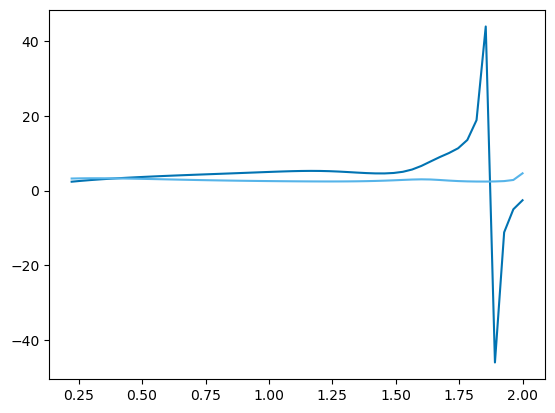

In [127]:
for (color, param) in zip(colors, ['G_1', 'G_2']): 

    plt.plot(df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, 'freq [Hz]'], np.divide(df_grouped_mean.loc[df_grouped_mean['MT_STATUS']=='y',param].values, df_grouped_mean.loc[df_grouped_mean['MT_STATUS']=='n',param].values), '-', color=color)

plt.show()